# **VGGNet-11 Implementation on CIFAR-10**

---
## **Project Overview**
In this notebook, we implement the **VGG-11** architecture from scratch using the Keras Sequential API. We optimize the original design for the CIFAR-10 dataset by:
*   Adding **Batch Normalization** to every layer.
*   Implementing **Data Augmentation** (flips and shifts).
*   Using **Global Average Pooling** to reduce parameter count and prevent overfitting.

In [ ]:
# ─── ALL IMPORTS AT THE TOP ──────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import logging
tf.get_logger().setLevel(logging.ERROR)

EPOCHS = 50
BATCH_SIZE = 64

## **1. Dataset Loading and Preprocessing**
The CIFAR-10 dataset contains 60,000 $32 \times 32$ color images in 10 classes.
1.  **Z-Score Normalization:** We normalize images using the global mean and standard deviation.
2.  **One-Hot Encoding:** Labels are converted to categorical vectors.
3.  **Augmentation:** We fit an `ImageDataGenerator` to improve model generalization.

In [ ]:
# ─── 1. Load Dataset & Preprocessing ──────────────────────────────────────────
cifar_dataset = keras.datasets.cifar10
(train_images, train_labels), (test_images, test_labels) = cifar_dataset.load_data()

mean   = np.mean(train_images)
stddev = np.std(train_images)
train_images = (train_images - mean) / stddev
test_images  = (test_images  - mean) / stddev

print('mean: ',   mean)
print('stddev: ', stddev)

train_labels = to_categorical(train_labels, num_classes=10)
test_labels  = to_categorical(test_labels,  num_classes=10)

# Setup Data Augmentation
datagen = ImageDataGenerator(
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(train_images)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 118s 1us/step
mean:  120.70756512369792
stddev:  64.1500758911213


## **2. Architecture Definition: VGG-11**
We define the 8 convolutional layers and 3 dense layers.
*   **Initialization:** `he_normal` for convolutions and `glorot_uniform` for dense layers.
*   **Regularization:** Dropout (0.5) is used in the classifier head.
*   **Optimizer:** Adam with a low learning rate ($10^{-4}$) for stable convergence.

In [ ]:
# ─── 2. Build VGG-11 ──────────
model = Sequential()

# ── Block 1: 1x C3D64 + BN + M ──
model.add(Conv2D(64, (3, 3), strides=(1, 1), activation='relu', padding='same',
                 input_shape=(32, 32, 3),
                 kernel_initializer='he_normal', bias_initializer='zeros'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# ── Block 2: 1x C3D128 + BN + M ──
model.add(Conv2D(128, (3, 3), strides=(1, 1), activation='relu', padding='same',
                 kernel_initializer='he_normal', bias_initializer='zeros'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# ── Block 3: 2x C3D256 + BN + M ──
model.add(Conv2D(256, (3, 3), strides=(1, 1), activation='relu', padding='same',
                 kernel_initializer='he_normal', bias_initializer='zeros'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3, 3), strides=(1, 1), activation='relu', padding='same',
                 kernel_initializer='he_normal', bias_initializer='zeros'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# ── Block 4: 2x C3D512 + BN + M ──
model.add(Conv2D(512, (3, 3), strides=(1, 1), activation='relu', padding='same',
                 kernel_initializer='he_normal', bias_initializer='zeros'))
model.add(BatchNormalization())
model.add(Conv2D(512, (3, 3), strides=(1, 1), activation='relu', padding='same',
                 kernel_initializer='he_normal', bias_initializer='zeros'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# ── Block 5: 2x C3D512 + BN + M ──
model.add(Conv2D(512, (3, 3), strides=(1, 1), activation='relu', padding='same',
                 kernel_initializer='he_normal', bias_initializer='zeros'))
model.add(BatchNormalization())
model.add(Conv2D(512, (3, 3), strides=(1, 1), activation='relu', padding='same',
                 kernel_initializer='he_normal', bias_initializer='zeros'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# ── Classifier Head (FC layers) ──
model.add(GlobalAveragePooling2D())

model.add(Dense(512, activation='relu',
                kernel_initializer='glorot_uniform', bias_initializer='zeros'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(512, activation='relu',
                kernel_initializer='glorot_uniform', bias_initializer='zeros'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# FC10 (Output)
model.add(Dense(10, activation='softmax',
                kernel_initializer='glorot_uniform', bias_initializer='zeros'))

my_optimizer = Adam(learning_rate=0.0001)

model.compile(loss='categorical_crossentropy',
              optimizer=my_optimizer,
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 2, 2, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 2, 2, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 1, 1, 512)      │             

 Total params: 9,766,026 (37.25 MB)

 Trainable params: 9,758,474 (37.23 MB)

 Non-trainable params: 7,552 (29.50 KB)

## **3. Model Training**
We train the network for 50 epochs. Because we are using an `ImageDataGenerator`, we use `datagen.flow` to supply augmented images to the model during training.

In [ ]:
# ─── 3. Train ────────────────────────────────────────────
history = model.fit(
    datagen.flow(train_images, train_labels, batch_size=BATCH_SIZE),
    validation_data=(test_images, test_labels),
    epochs=EPOCHS,
    verbose=2
)

Epoch 1/50
782/782 - 67s - 86ms/step - accuracy: 0.3044 - loss: 2.3662 - val_accuracy: 0.4725 - val_loss: 1.5706
Epoch 2/50
782/782 - 38s - 49ms/step - accuracy: 0.4347 - loss: 1.7371 - val_accuracy: 0.5523 - val_loss: 1.3093
Epoch 3/50
782/782 - 38s - 49ms/step - accuracy: 0.5096 - loss: 1.4546 - val_accuracy: 0.6119 - val_loss: 1.1457
Epoch 4/50
782/782 - 38s - 49ms/step - accuracy: 0.5631 - loss: 1.2701 - val_accuracy: 0.6345 - val_loss: 1.0621
Epoch 5/50
782/782 - 38s - 48ms/step - accuracy: 0.6078 - loss: 1.1273 - val_accuracy: 0.6773 - val_loss: 0.9125
Epoch 6/50
782/782 - 39s - 49ms/step - accuracy: 0.6458 - loss: 1.0164 - val_accuracy: 0.6996 - val_loss: 0.8689
Epoch 7/50
782/782 - 38s - 49ms/step - accuracy: 0.6739 - loss: 0.9375 - val_accuracy: 0.7194 - val_loss: 0.8148
Epoch 8/50
782/782 - 38s - 49ms/step - accuracy: 0.7037 - loss: 0.8608 - val_accuracy: 0.6982 - val_loss: 0.9212
Epoch 9/50
782/782 - 38s - 49ms/step - accuracy: 0.7247 - loss: 0.7993 - val_accuracy: 0.7273 - 

## **4. Performance Visualization**
We evaluate the learning curves to check for overfitting and monitor the validation accuracy.
*   **Error Plot:** $1 - Accuracy$
*   **Loss Plot:** Categorical Crossentropy
*   **Accuracy Plot:** Correct Prediction Percentage

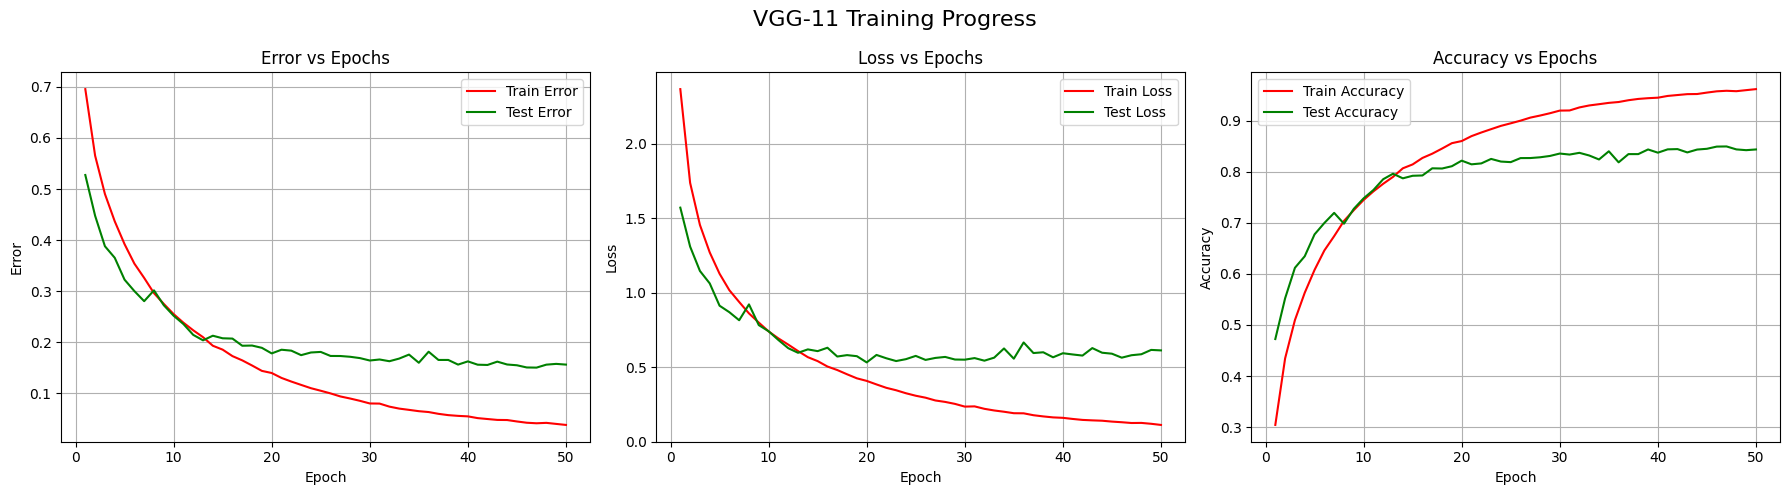

In [ ]:
# ─── 4 & 5. Plot: Error, Loss, and Accuracy ─────────────────────
train_error =[1 - acc for acc in history.history['accuracy']]
test_error  = [1 - acc for acc in history.history['val_accuracy']]
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(18, 5))

# Plot 1: Error
plt.subplot(1, 3, 1)
plt.plot(epochs_range, train_error, color='red',   label='Train Error')
plt.plot(epochs_range, test_error,  color='green', label='Test Error')
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.title('Error vs Epochs')
plt.legend()
plt.grid(True)

# Plot 2: Loss
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history.history['loss'],     label='Train Loss',  color='red')
plt.plot(epochs_range, history.history['val_loss'], label='Test Loss',   color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.grid(True)

# Plot 3: Accuracy
plt.subplot(1, 3, 3)
plt.plot(epochs_range, history.history['accuracy'],     label='Train Accuracy', color='red')
plt.plot(epochs_range, history.history['val_accuracy'], label='Test Accuracy',  color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.grid(True)

plt.suptitle('VGG-11 Training Progress', fontsize=16)
plt.tight_layout()
plt.show()

## **5. Inference & Qualitative Analysis**
We perform predictions on 16 sample images from the test set to visually confirm model performance.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 853ms/step


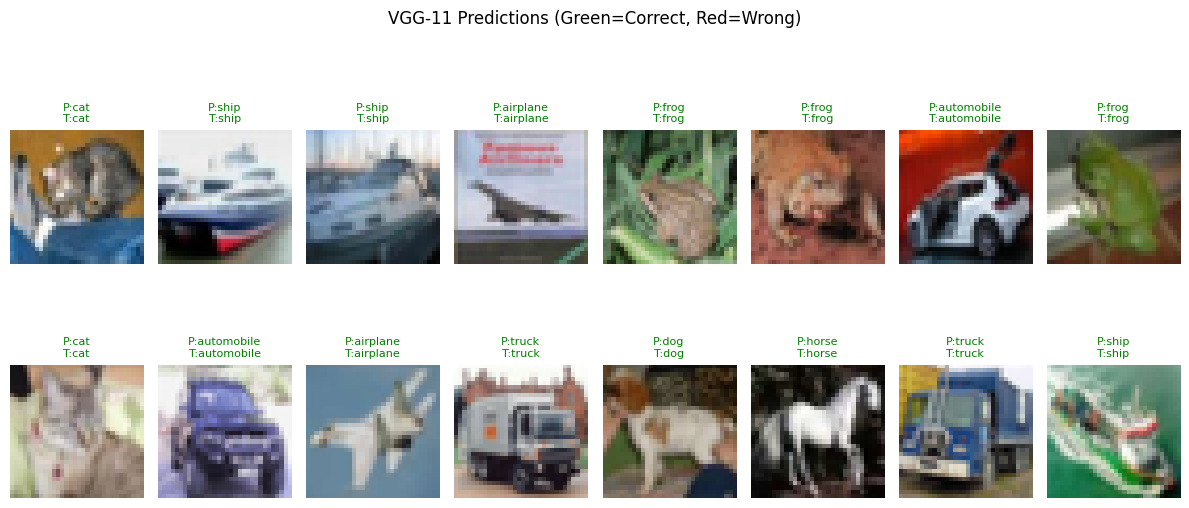

In [ ]:
# ─── 6. Sample Predictions ────────────────────────────────────────────────────
class_names =['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

(_, _), (raw_test_images, raw_test_labels) = cifar_dataset.load_data()

predictions  = model.predict(test_images[:16])
pred_classes = np.argmax(predictions, axis=1)
true_classes = raw_test_labels[:16].flatten()

plt.figure(figsize=(12, 6))
for i in range(16):
    plt.subplot(2, 8, i+1)
    plt.imshow(raw_test_images[i])
    color = 'green' if pred_classes[i] == true_classes[i] else 'red'
    plt.title(f'P:{class_names[pred_classes[i]]}\nT:{class_names[true_classes[i]]}',
              fontsize=8, color=color)
    plt.axis('off')

plt.suptitle('VGG-11 Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout()
plt.show()

## **6. Final Evaluation: Confusion Matrix**
The confusion matrix helps identify which classes are most commonly confused by the model.


Generating Confusion Matrix...
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step


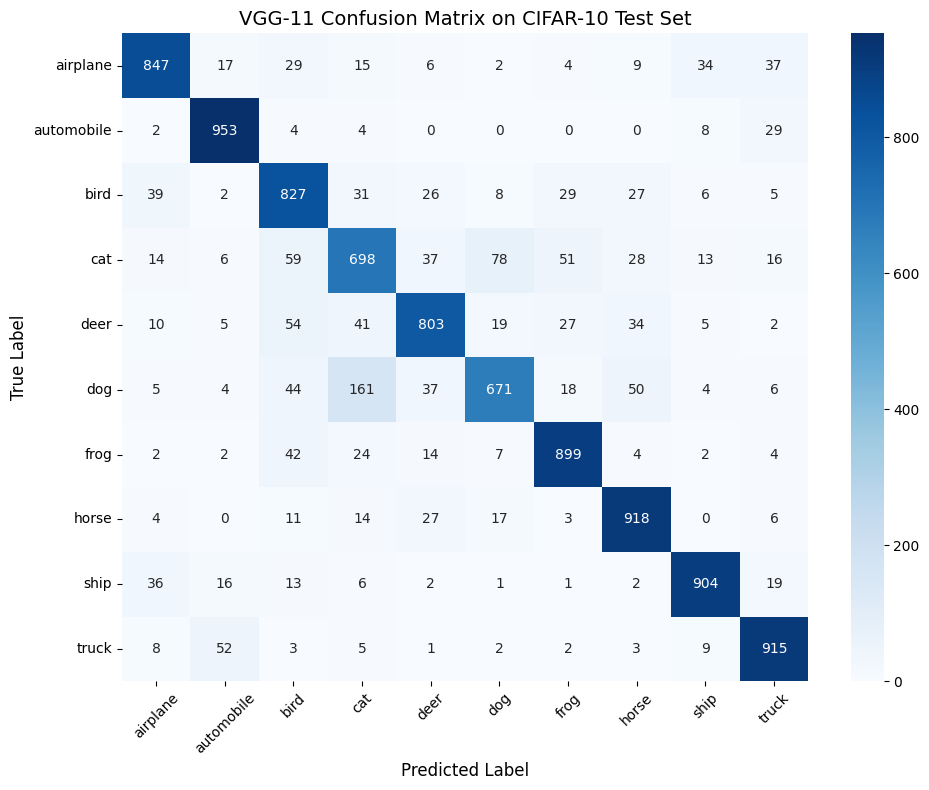

In [ ]:
# ─── 7. Confusion Matrix ────────────────────────────────────────────────
print("\nGenerating Confusion Matrix...")

all_predictions = model.predict(test_images, batch_size=BATCH_SIZE)
all_pred_classes = np.argmax(all_predictions, axis=1)
all_true_classes = np.argmax(test_labels, axis=1)

cm = confusion_matrix(all_true_classes, all_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('VGG-11 Confusion Matrix on CIFAR-10 Test Set', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()